In [1]:
"""
UFC Fight Outcome Predictor
----------------------------
Predicts whether the Red corner fighter wins a UFC fight
using pre-fight historical statistics.

Key design decisions:
- Explicit feature whitelist (no keyword guessing) to prevent silent leakage
- Temporal split — train on past, test on future
- Imputation and scaling fit only on training data (inside Pipeline)
- TimeSeriesSplit CV for robust model selection
- Calibration curve to verify probability reliability
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              roc_curve, ConfusionMatrixDisplay)
from sklearn.calibration import CalibrationDisplay
from xgboost import XGBClassifier


In [2]:
# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
ufc      = pd.read_csv("data/UFC.csv")
fights   = pd.read_csv("data/fight_details.csv")
events   = pd.read_csv("data/event_details.csv")
fighters = pd.read_csv("data/fighter_details.csv")


In [3]:
# ─────────────────────────────────────────────
# 2. MERGE & BUILD TARGET
# ─────────────────────────────────────────────
df = ufc.merge(
    fights[["fight_id", "r_name", "b_name"]],
    on="fight_id",
    how="left",
    suffixes=("", "_fights")
)
df = df.copy()

r_col = "r_name" if "r_name" in df.columns else "r_name_fights"

# Binary target: 1 = Red wins, 0 = Blue wins
df["red_win"] = (df["winner"] == df[r_col]).astype(int)

assert df["red_win"].sum() > 0, "red_win is all zeros — check column names"

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Dataset: {len(df)} fights")
print(f"Red wins: {df['red_win'].mean():.1%}  |  Blue wins: {1-df['red_win'].mean():.1%}")


Dataset: 8337 fights
Red wins: 63.5%  |  Blue wins: 36.5%


In [4]:
# ─────────────────────────────────────────────
# 3. FEATURE SELECTION
# ─────────────────────────────────────────────
# ARREGLO 1: whitelist explícita en vez de filtrado por keywords.
#
# Antes: se usaban keywords ("avg", "acc", etc.) para incluir/excluir columnas.
# Problema: frágil. Si el dataset cambia o agrega columnas con esos patrones,
# podría colar features post-fight sin que te des cuenta.
#
# Ahora: lista explícita de las únicas columnas que sabemos que son
# estadísticas históricas pre-fight. Cualquier columna nueva queda fuera
# por defecto hasta que la agregues conscientemente.

PRE_FIGHT_FEATURES = [
    # Red corner — historical aggregates
    "r_str_acc", "r_sapm", "r_splm", "r_str_def",
    "r_td_avg",  "r_td_avg_acc", "r_td_def", "r_sub_avg",
    # Blue corner — historical aggregates
    "b_str_acc", "b_sapm", "b_splm", "b_str_def",
    "b_td_avg",  "b_td_avg_acc", "b_td_def", "b_sub_avg",
]

# Keep only columns that actually exist in this dataset
PRE_FIGHT_FEATURES = [c for c in PRE_FIGHT_FEATURES if c in df.columns]

X = df[PRE_FIGHT_FEATURES].copy()
y = df["red_win"]

print(f"Pre-fight features used: {len(PRE_FIGHT_FEATURES)}")
print(PRE_FIGHT_FEATURES)


Pre-fight features used: 16
['r_str_acc', 'r_sapm', 'r_splm', 'r_str_def', 'r_td_avg', 'r_td_avg_acc', 'r_td_def', 'r_sub_avg', 'b_str_acc', 'b_sapm', 'b_splm', 'b_str_def', 'b_td_avg', 'b_td_avg_acc', 'b_td_def', 'b_sub_avg']


In [5]:
# ─────────────────────────────────────────────
# 4. FEATURE ENGINEERING — Differential features
# ─────────────────────────────────────────────
# Instead of giving the model r_td_avg and b_td_avg separately,
# we give it the direct difference. Linear models capture this
# much more efficiently — they don't have to discover the
# subtraction themselves.
#
# Note: these are simple arithmetic combinations of existing columns,
# so they don't introduce leakage regardless of where the split is.

diff_cols = []
for col in PRE_FIGHT_FEATURES:
    if col.startswith("r_"):
        blue_col = col.replace("r_", "b_", 1)
        if blue_col in X.columns:
            diff_name = col.replace("r_", "", 1) + "_diff"
            X[diff_name] = X[col] - X[blue_col]
            diff_cols.append(diff_name)

print(f"Differential features added: {len(diff_cols)}")
print(f"Total features: {X.shape[1]}")


Differential features added: 8
Total features: 24


In [6]:
# ─────────────────────────────────────────────
# 5. TIME SERIES CROSS-VALIDATION
# ─────────────────────────────────────────────
# ARREGLO 2: instancias frescas de cada modelo en cada fold.
#
# Antes: el dict "models" se definía una sola vez y se reutilizaba en todos
# los folds. Problema: después del CV, esos objetos ya estaban entrenados
# con datos del último fold. Usarlos después en el split final significaba
# que el modelo NO era realmente nuevo — podía tener estado residual.
#
# Ahora: una función get_models() devuelve instancias nuevas cada vez que
# se llama. Así cada fold y el split final arrancan desde cero.

def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=10000),
        "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
        "XGBoost":             XGBClassifier(n_estimators=200, random_state=42,
                                             eval_metric="logloss", verbosity=0),
    }

tscv = TimeSeriesSplit(n_splits=5)
cv_results = {}

print(f"\n{'─'*65}")
print(f"  {'Modelo':<25} {'Mean AUC':>10} {'Std AUC':>10}  Folds")
print(f"{'─'*65}")

for name, clf in get_models().items():
    fold_aucs = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_cv_train = X.iloc[train_idx]
        X_cv_test  = X.iloc[test_idx]
        y_cv_train = y.iloc[train_idx]
        y_cv_test  = y.iloc[test_idx]

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler",  StandardScaler()),
            ("model",   clf)
        ])
        pipe.fit(X_cv_train, y_cv_train)
        probs_cv = pipe.predict_proba(X_cv_test)[:, 1]
        fold_aucs.append(roc_auc_score(y_cv_test, probs_cv))

    cv_results[name] = {
        "mean_auc":   np.mean(fold_aucs),
        "std_auc":    np.std(fold_aucs),
        "fold_aucs":  fold_aucs,
    }

    fold_str = "  ".join([f"{v:.3f}" for v in fold_aucs])
    print(f"  {name:<25} {np.mean(fold_aucs):>10.3f} {np.std(fold_aucs):>10.3f}  [{fold_str}]")

print(f"{'─'*65}")

best_name = max(cv_results, key=lambda k: cv_results[k]["mean_auc"])
print(f"\n  Mejor modelo: {best_name} (Mean AUC {cv_results[best_name]['mean_auc']:.3f})")
print(f"  Std AUC: {cv_results[best_name]['std_auc']:.3f}  ", end="")
if cv_results[best_name]["std_auc"] < 0.02:
    print("→ modelo estable entre folds ✓")
elif cv_results[best_name]["std_auc"] < 0.04:
    print("→ varianza moderada, aceptable")
else:
    print("→ varianza alta, interpretar con cuidado")



─────────────────────────────────────────────────────────────────
  Modelo                      Mean AUC    Std AUC  Folds
─────────────────────────────────────────────────────────────────
  Logistic Regression            0.667      0.030  [0.632  0.653  0.659  0.671  0.722]
  Random Forest                  0.667      0.027  [0.627  0.671  0.657  0.668  0.712]
  XGBoost                        0.650      0.020  [0.620  0.667  0.645  0.644  0.675]
─────────────────────────────────────────────────────────────────

  Mejor modelo: Logistic Regression (Mean AUC 0.667)
  Std AUC: 0.030  → varianza moderada, aceptable


In [7]:
# ─────────────────────────────────────────────
# 6. FINAL EVALUATION — Temporal split 80/20
# ─────────────────────────────────────────────
# ARREGLO 3: se eliminó la celda "FINAL TRAINING ON FULL DATASET".
#
# Antes: había una Cell 5 que entrenaba el modelo en todo el dataset (X, y)
# y luego una Cell 6 que hacía el split 80/20. El problema era doble:
#   a) Cell 5 entrenaba en datos futuros del test — eso es leakage si se
#      usara ese pipeline para reportar métricas (aunque no se usaba).
#   b) Cell 5 no se usaba en ningún lado, era código muerto que confundía.
#
# Ahora: solo existe este split temporal limpio. El modelo se instancia
# desde cero con get_models() para evitar cualquier estado residual del CV.

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

# Fresh instance — not reusing any object from CV
final_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler",  StandardScaler()),
    ("model",   get_models()[best_name])
])

final_pipeline.fit(X_train, y_train)

probs = final_pipeline.predict_proba(X_test)[:, 1]
preds = (probs > 0.5).astype(int)

baseline = y_test.value_counts(normalize=True).max()
accuracy = accuracy_score(y_test, preds)
auc      = roc_auc_score(y_test, probs)

print(f"\n{'─'*40}")
print(f"  Baseline (majority class) : {baseline:.3f}")
print(f"  Accuracy                  : {accuracy:.3f}")
print(f"  AUC-ROC                   : {auc:.3f}")
print(f"{'─'*40}")
print(f"  Train: {len(X_train)} fights  |  Test: {len(X_test)} fights")



────────────────────────────────────────
  Baseline (majority class) : 0.554
  Accuracy                  : 0.651
  AUC-ROC                   : 0.712
────────────────────────────────────────
  Train: 6669 fights  |  Test: 1668 fights


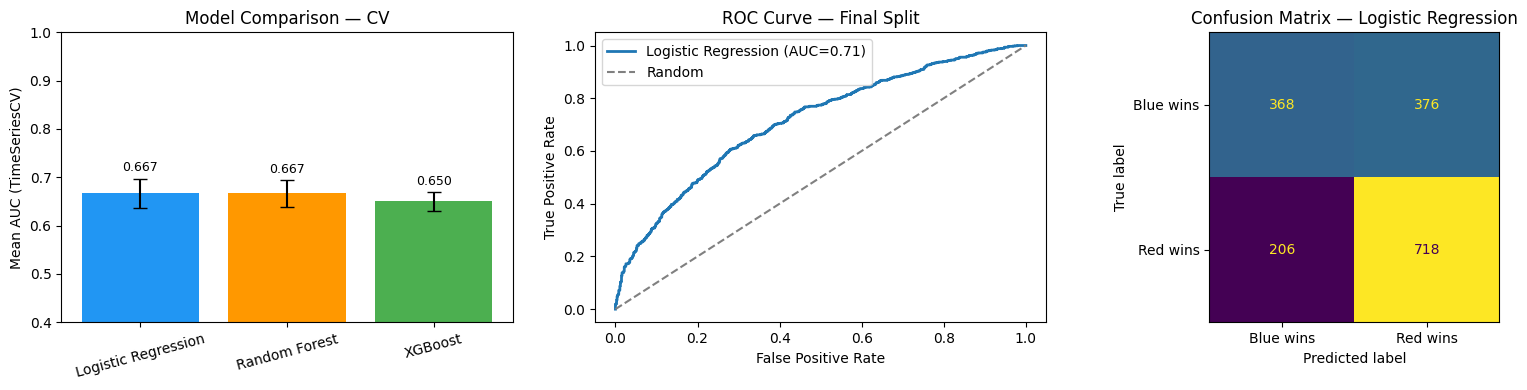

In [8]:
# ─────────────────────────────────────────────
# 7. EVALUATION PLOTS
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 7a. CV AUC comparison with error bars
model_names = list(cv_results.keys())
mean_aucs   = [cv_results[n]["mean_auc"] for n in model_names]
std_aucs    = [cv_results[n]["std_auc"]  for n in model_names]
colors      = ["#2196F3", "#FF9800", "#4CAF50"]

axes[0].bar(model_names, mean_aucs, yerr=std_aucs,
            color=colors, capsize=5, error_kw={"linewidth": 1.5})
axes[0].set_ylim(0.4, 1.0)
axes[0].set_ylabel("Mean AUC (TimeSeriesCV)")
axes[0].set_title("Model Comparison — CV")
axes[0].tick_params(axis="x", rotation=15)
for i, (v, s) in enumerate(zip(mean_aucs, std_aucs)):
    axes[0].text(i, v + s + 0.015, f"{v:.3f}", ha="center", fontsize=9)

# 7b. ROC Curve
fpr_, tpr_, _ = roc_curve(y_test, probs)
axes[1].plot(fpr_, tpr_, label=f"{best_name} (AUC={auc:.2f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Final Split")
axes[1].legend()

# 7c. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, preds,
    display_labels=["Blue wins", "Red wins"],
    ax=axes[2], colorbar=False
)
axes[2].set_title(f"Confusion Matrix — {best_name}")

plt.tight_layout()
plt.savefig("data/github/results/evaluation_plots.png", dpi=150)
plt.show()


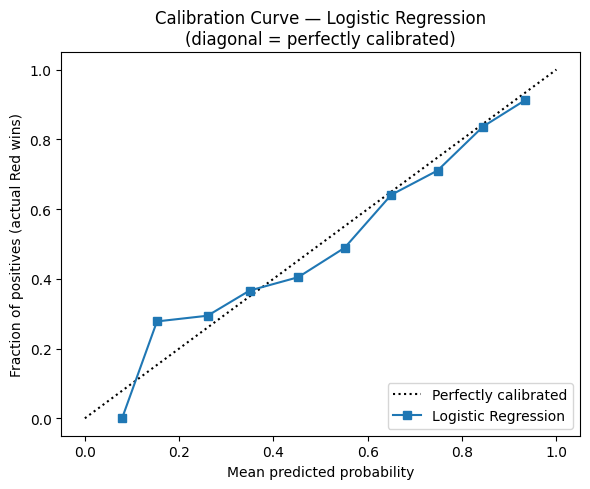

In [9]:
# ─────────────────────────────────────────────
# 8. CALIBRATION CURVE
# ─────────────────────────────────────────────
# ARREGLO 4: curva de calibración agregada.
#
# Un AUC alto dice que el modelo rankea bien, pero no dice si las
# probabilidades son confiables. Si el modelo predice 80% de chance
# para Red, ¿gana Red realmente el 80% de las veces?
# Eso lo muestra la calibration curve.
#
# Línea diagonal perfecta = probabilidades confiables.
# Curva por debajo = modelo sobreconfiado (predice probabilidades muy extremas).
# Curva por arriba = modelo subconfiado (probabilidades muy conservadoras).

fig, ax = plt.subplots(figsize=(6, 5))

CalibrationDisplay.from_predictions(
    y_test, probs,
    n_bins=10,
    ax=ax,
    name=best_name
)

ax.set_title(f"Calibration Curve — {best_name}\n"
             "(diagonal = perfectly calibrated)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (actual Red wins)")

plt.tight_layout()
plt.savefig("data/results/calibration_curve.png", dpi=150)
plt.show()


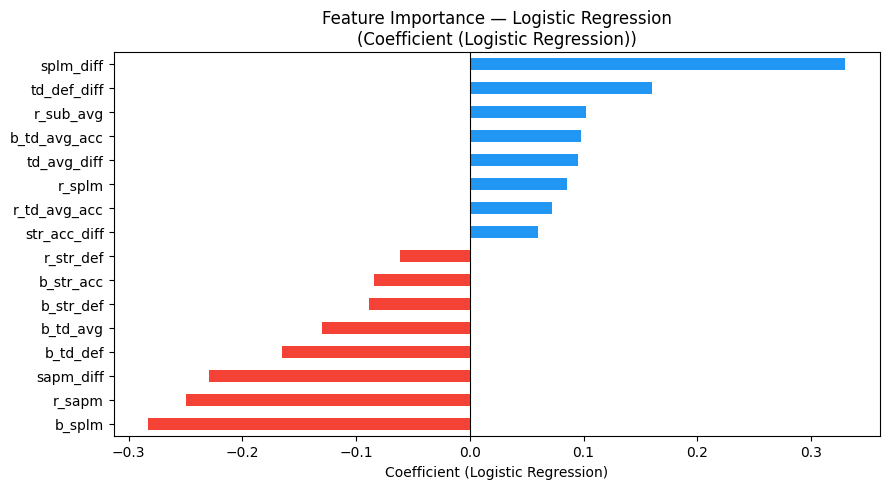

In [10]:
# ─────────────────────────────────────────────
# 9. FEATURE IMPORTANCE
# ─────────────────────────────────────────────
# ARREGLO 5: se usa X_train.columns directamente del split final,
# que es el mismo X que vio el pipeline. Antes había un riesgo de
# desalineación si X_train hubiera sido modificado entre celdas.

best_clf     = final_pipeline.named_steps["model"]
feature_names = list(X_train.columns)

if hasattr(best_clf, "coef_"):
    importances   = best_clf.coef_[0]
    imp_label     = "Coefficient (Logistic Regression)"
else:
    importances   = best_clf.feature_importances_
    imp_label     = "Feature Importance (Gini)"

imp_series = pd.Series(importances, index=feature_names).sort_values()

# Show top 8 and bottom 8 to keep the chart readable
imp_plot = pd.concat([imp_series.head(8), imp_series.tail(8)])

fig, ax = plt.subplots(figsize=(9, 5))
imp_plot.plot(
    kind="barh", ax=ax,
    color=["#F44336" if v < 0 else "#2196F3" for v in imp_plot]
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Feature Importance — {best_name}\n({imp_label})")
ax.set_xlabel(imp_label)
plt.tight_layout()
plt.savefig("data/results/feature_importance.png", dpi=150)
plt.show()
